# Attention and the Transformer Architecture
You are part of a product team tasked with improving a translation service. While your previous LSTMs (from Practical 4) worked, they struggled with very long sentences, often forgetting the early context. The management wants to upgrade the system using the Attention Mechanism to focus on the most relevant parts of the source sentence, followed by migrating to the state-of-the-art Transformer architecture.
Your task is to implement the core mathematical concept of Attention and then use a pre-trained Transformer to demonstrate its power in a practical application.

In [1]:
# Import

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Part A: Implementing Dot-Product Attention (The Core Math)

### Task A.1: The QKV Interaction
Implement a Python function `dot_product_attention(Q, K, V, mask=None)`:

1. Calculate the Attention Scores by taking the dot product of the Query (Q) and the Key (K), and scaling by :
    * Action: Use `torch.bmm` or matrix multiplication.
2. Apply a Softmax function over the scores to obtain the Attention Weights.

3. Calculate the final Context Vector by multiplying the weights by the Value (V) matrix.


In [2]:
def dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)

    scores = torch.bmm(Q, K.transpose(1, 2)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    attention_weights = F.softmax(scores, dim=-1)

    context = torch.bmm(attention_weights, V)

    return context, attention_weights

In [3]:
def test_attention():
    torch.manual_seed(42)  # For reproducibility

    batch_size = 2
    seq_len_q = 3
    seq_len_k = 4
    d_k = 5
    d_v = 6

    # Random tensors
    Q = torch.randn(batch_size, seq_len_q, d_k)
    K = torch.randn(batch_size, seq_len_k, d_k)
    V = torch.randn(batch_size, seq_len_k, d_v)

    context, weights = dot_product_attention(Q, K, V)

    print("Q shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)
    print("\nAttention Weights shape:", weights.shape)
    print("Context shape:", context.shape)

    # Check softmax property
    print("\nSum of attention weights (should be 1):")
    print(weights.sum(dim=-1))

    # Example mask (masking last key position)
    mask = torch.ones(batch_size, seq_len_q, seq_len_k)
    mask[:, :, -1] = 0

    context_masked, weights_masked = dot_product_attention(Q, K, V, mask)

    print("\nMasked attention weights (last column should be ~0):")
    print(weights_masked)



test_attention()

Q shape: torch.Size([2, 3, 5])
K shape: torch.Size([2, 4, 5])
V shape: torch.Size([2, 4, 6])

Attention Weights shape: torch.Size([2, 3, 4])
Context shape: torch.Size([2, 3, 6])

Sum of attention weights (should be 1):
tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]])

Masked attention weights (last column should be ~0):
tensor([[[0.0790, 0.8913, 0.0297, 0.0000],
         [0.7132, 0.0302, 0.2565, 0.0000],
         [0.2799, 0.5694, 0.1507, 0.0000]],

        [[0.2982, 0.4433, 0.2585, 0.0000],
         [0.2345, 0.2617, 0.5039, 0.0000],
         [0.6128, 0.3037, 0.0835, 0.0000]]])


### Task A.2: Visualizing Attention
Select a short example sentence and manually create mock Q, K, and V tensors.
1. Run the `dot_product_attention` function.
2. Visualize the generated Attention Weights Matrix (e.g., using a heatmap from `matplotlib` or `seaborn`). This plot should demonstrate which input words the model is focusing on when calculating the output for a specific word.


In [4]:
def visualize_attention(weights, tokens):
    attention_matrix = weights[0].detach().numpy()

    plt.figure()
    sns.heatmap(attention_matrix, annot=True)
    plt.xticks(range(len(tokens)), tokens)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.title("Attention Weights Heatmap")
    plt.show()

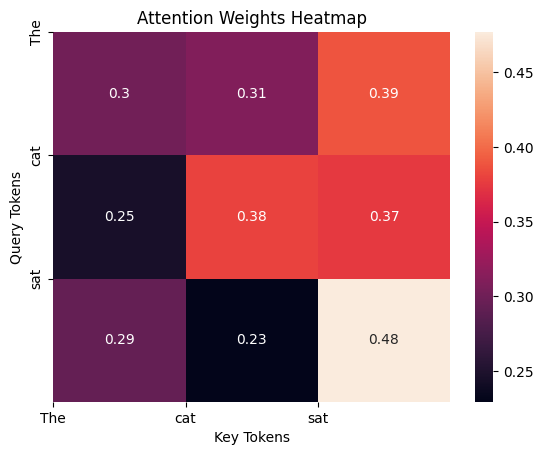

In [5]:
# 1. Setup Mock Data
torch.manual_seed(42) # Set seed for reproducibility

sentence = ["The", "cat", "sat"]
batch_size = 1
seq_len = len(sentence)
d_k = 4  # Embedding dimension (kept small for example)

# Create random mock tensors for Q, K, V
torch.manual_seed(42)
Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

# 2. Run Dot-Product Attention
context, weights = dot_product_attention(Q, K, V)

# 3. Visualize
visualize_attention(weights, sentence)

## Part B: Applying a Pre-trained Transformer

### Task B.1: Zero-Shot Sequence-to-Sequence (Translation)
Leverage the Hugging Face transformers library, which utilizes the full architecture (Encoder-Decoder) described in the "Attention is All You Need" paper.

1. Load a pre-trained Seq2Seq model, such as **T5** (`t5-small`) or **mBART** (`mbart-large-50`), and its corresponding tokenizer.
    * Action: Use `AutoTokenizer.from_pretrained(...)` and `AutoModelForSeq2SeqLM.from_pretrained(...)`.
2. Perform a **zero-shot translation** (e.g., `English to German/French`) on a sample sentence. You must correctly format the input prompt, including the task instruction (e.g., "`translate English to German: ...`" for T5).
3. Use the model's `generate()` method to obtain the translated output.


In [6]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast

In [7]:
def translate_text(text, target_lang="German"):
    if target_lang.lower() == "german":
        model_name = "Helsinki-NLP/opus-mt-en-de"
    elif target_lang.lower() == "french":
        model_name = "Helsinki-NLP/opus-mt-en-fr"
    else:
        raise ValueError("Unsupported language")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    inputs = tokenizer(text, return_tensors="pt")
    outputs = model.generate(**inputs)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [8]:
model_name = "facebook/mbart-large-50-many-to-many-mmt"
mbart_tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
mbart_model = MBartForConditionalGeneration.from_pretrained(model_name)

def translate_with_mbart(text, target_lang_code="de_DE"):
    mbart_tokenizer.src_lang = "en_XX"
    encoded = mbart_tokenizer(text, return_tensors="pt")

    generated_tokens = mbart_model.generate(
        **encoded,
        forced_bos_token_id=mbart_tokenizer.lang_code_to_id[target_lang_code]
    )

    return mbart_tokenizer.decode(generated_tokens[0], skip_special_tokens=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

In [9]:
# Sample Sentence
english_text = "The transformer model is powerful and efficient."

# Simple Translation
german_translation = translate_text(english_text, target_lang="German")
french_translation = translate_text(english_text, target_lang="French")

print("-" * 30)
print(f"Original: {english_text}")
print(f"German:   {german_translation}")
print(f"French:   {french_translation}")

# mBART Translation
german_translation = translate_with_mbart(english_text, target_lang_code="de_DE")
french_translation = translate_with_mbart(english_text, target_lang_code="fr_XX")

print("-" * 30)
print(f"Original: {english_text}")
print(f"German:   {german_translation}")
print(f"French:   {french_translation}")

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


------------------------------
Original: The transformer model is powerful and efficient.
German:   Das Transformatorenmodell ist leistungsstark und effizient.
French:   Le modèle de transformateur est puissant et efficace.
------------------------------
Original: The transformer model is powerful and efficient.
German:   Das Transformatormodell ist leistungsstark und effizient.
French:   Le modèle de transformateur est puissant et efficace.


### Task B.2: The Need for Positional Encoding (Theoretical)
The Transformer removes the sequential processing of RNNs, making all tokens independent. Explain (in a brief text block in the notebook) why this is a problem and how Positional Encoding (a fixed or learned vector added to the word embedding) is essential to re-introduce the notion of word order into the model.


The Transformer processes all tokens in parallel using self-attention, which means it has no inherent understanding of sequence order. Unlike RNNs, which process tokens sequentially and naturally encode position through recurrence, the Transformer treats input tokens as a set rather than an ordered sequence. This creates a problem because word order is crucial for meaning (e.g., “dog bites man” vs. “man bites dog”).

Positional Encoding solves this issue by adding a position-dependent vector to each word embedding. These encodings (either fixed sinusoidal patterns or learned vectors) inject information about token positions into the model, allowing the Transformer to distinguish between different word orders while still benefiting from parallel processing.

## Deliverables
1. A fully executed Python Notebook (.ipynb) implementing the Dot-Product Attention function and the zero-shot translation using a Hugging Face Transformer model.
2. **Visualization:** The heatmap of the Attention Weights Matrix from Task A.2.
3. **Analysis:** A concise answer (approx. 100 words) to the question: What is the primary computational advantage of using Self-Attention (within the Transformer) over the Recurrent connection (in LSTMs) when processing long sequences? (Hint: Think about parallel processing).


The primary computational advantage of Self-Attention over recurrent models like LSTMs is parallelization. LSTMs process tokens sequentially because each time step depends on the previous hidden state, preventing efficient parallel computation. In contrast, Self-Attention computes relationships between all tokens simultaneously using matrix multiplications. This allows full parallel processing on GPUs, significantly accelerating training and inference for long sequences. Additionally, Self-Attention provides direct connections between distant tokens without relying on step-by-step information flow, reducing vanishing gradient issues and improving the modeling of long-range dependencies. This architectural difference makes Transformers more scalable and efficient than recurrent networks for large-scale sequence tasks.